In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from dataset import get_flattened_data, class_names, load_fashion_mnist
from pathlib import Path

BASE_DIR = Path.cwd()
RESULTS_DIR = BASE_DIR / "results"


In [9]:
X_train, y_train, X_test, y_test = load_fashion_mnist()

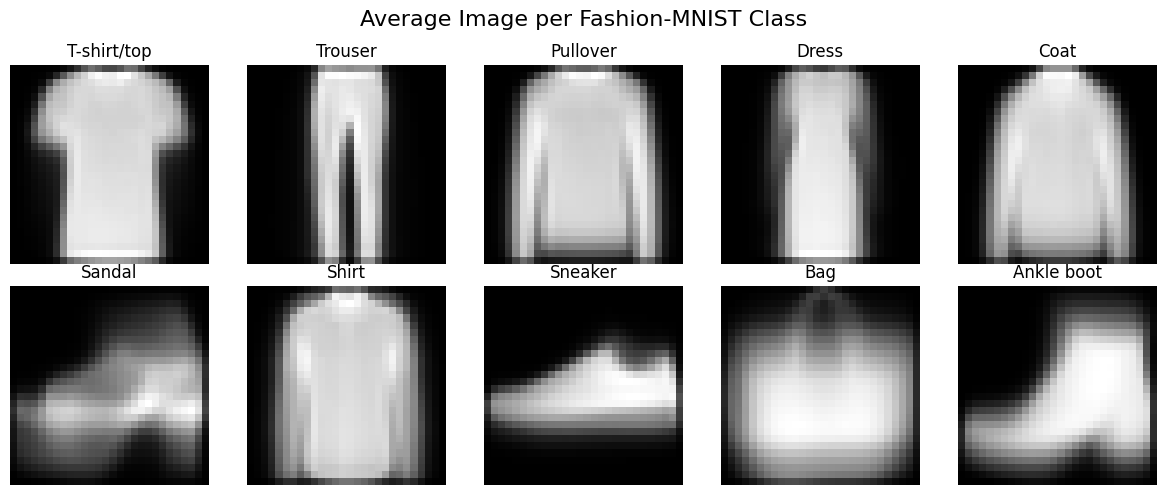

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    class_images = X_train[y_train == i]
    average_image = np.mean(class_images, axis=0)

    # 4. Plot it
    axes[i].imshow(average_image, cmap='gray')
    axes[i].set_title(class_names[i])
    axes[i].axis('off')

plt.suptitle("Average Image per Fashion-MNIST Class", fontsize=16)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "average_class_images.png")
plt.show()

In [12]:
print(f"Training data (X_train): {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Training labels (y_train): {y_train.shape[0]} labels")
print(f"Test data (X_test): {X_test.shape[0]} rows, {X_test.shape[1]} features")
print(f"Test labels (y_test): {y_test.shape[0]} labels\n")

unique_classes, class_counts = np.unique(y_train, return_counts=True)

# Check if classes are integers or strings and map to names
for cls, count in zip(unique_classes, class_counts):
    class_idx = int(cls)
    print(f"{class_names[class_idx]:<15}: {count} images ({count/len(y_train)*100:.1f}%)")
print()

print(f"Minimum pixel value: {np.min(X_train)}")
print(f"Maximum pixel value: {np.max(X_train)}")
print(f"Mean pixel value:    {np.mean(X_train):.2f}")
print(f"Standard deviation:  {np.std(X_train):.2f}\n")

missing_train = np.isnan(X_train).sum()
missing_test = np.isnan(X_test).sum()
print(f"Missing values (NaN) in training data: {missing_train}")
print(f"Missing values (NaN) in test data:     {missing_test}")

fashion_classes = [
'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]



Training data (X_train): 60000 rows, 28 features
Training labels (y_train): 60000 labels
Test data (X_test): 10000 rows, 28 features
Test labels (y_test): 10000 labels

T-shirt/top    : 6000 images (10.0%)
Trouser        : 6000 images (10.0%)
Pullover       : 6000 images (10.0%)
Dress          : 6000 images (10.0%)
Coat           : 6000 images (10.0%)
Sandal         : 6000 images (10.0%)
Shirt          : 6000 images (10.0%)
Sneaker        : 6000 images (10.0%)
Bag            : 6000 images (10.0%)
Ankle boot     : 6000 images (10.0%)

Minimum pixel value: 0.0
Maximum pixel value: 1.0
Mean pixel value:    0.29
Standard deviation:  0.35

Missing values (NaN) in training data: 0
Missing values (NaN) in test data:     0


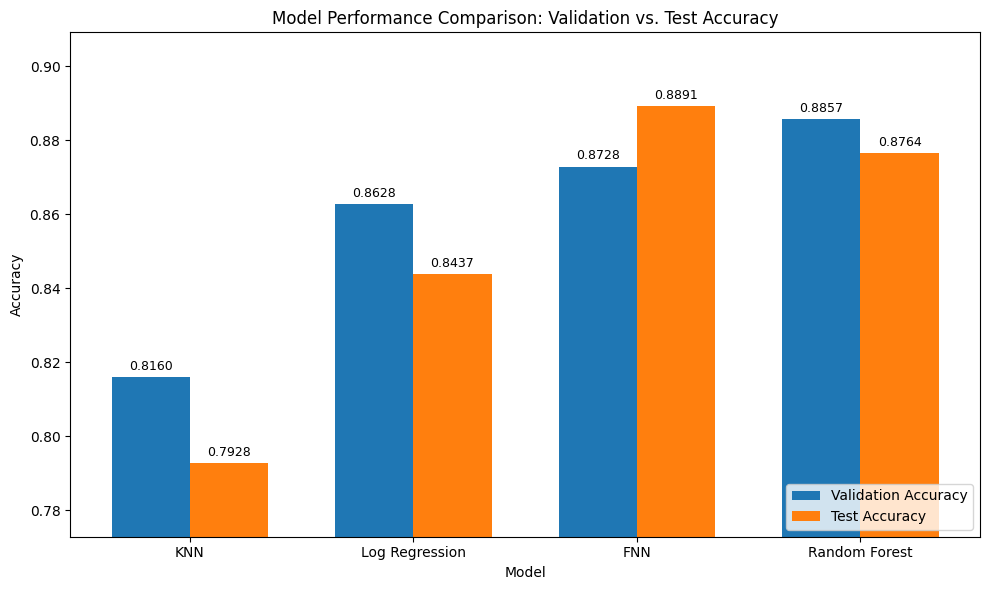

In [16]:
models = ['KNN', 'Log Regression', 'FNN', 'Random Forest']
val_accuracies = [0.8160, 0.8628, 0.8728, 0.8857]
test_accuracies = [0.7928, 0.8437, 0.8891, 0.8764]

# 2. Setup positions for the grouped bars
x = np.arange(len(models))  # The center locations for the groups
width = 0.35                # The width of the individual bars

fig, ax = plt.subplots(figsize=(10, 6))

# 3. Create the grouped bars
bars_val = ax.bar(x - width/2, val_accuracies, width,
                  label='Validation Accuracy',)
bars_test = ax.bar(x + width/2, test_accuracies, width,
                   label='Test Accuracy')

# 4. Add labels, title, and formatting
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Model Performance Comparison: Validation vs. Test Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='lower right') # Kept at bottom right so it doesn't block the bars

# 5. Dynamic Scaling (zooms in on the differences)
all_accs = val_accuracies + test_accuracies
min_acc = min(all_accs)
max_acc = max(all_accs)
ax.set_ylim(min_acc - 0.02, max_acc + 0.02)

# 6. Add the exact numbers on top of the bars
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_labels(bars_val)
add_labels(bars_test)

plt.tight_layout()

# Uncomment the line below to save it to your results folder
plt.savefig(RESULTS_DIR / 'final_model_comparison.png')

plt.show()